In [1]:
#IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# SETUP HARDWARE ACCELERATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [45]:
# SETUP DATASETS

transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(32, scale=(0.8, 1.0)), # Forces the model to learn zoom-invariant features
    v2.RandomRotation(degrees=15),
    v2.ToTensor(),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Download the training and testing sets automatically
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)

# DataLoaders handle batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


10000

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


torch.Size([64, 3, 32, 32])


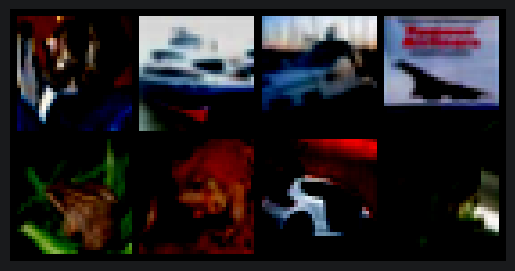

In [6]:

data_iter = iter(test_loader)
img, out = next(data_iter)
print(img.size())

grid_img = torchvision.utils.make_grid(img[:8], nrow=4, padding=2)
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [7]:
image, label = train_dataset[0]

In [8]:
image.size()

torch.Size([3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].


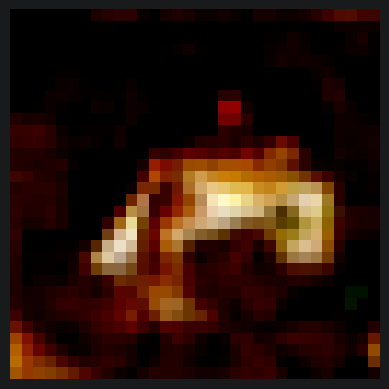

In [9]:
plt.imshow(image.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [10]:
label #dog

6

In [26]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [51]:
# Neural network
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 channels (RGB), 32x32 image size, 3x3 kernel, 1 padding output image size: 32x
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=15, kernel_size=5)
        # [deprecated]Max pooling half, in 28x28 image, output 14x14 image, relu
        self.batchnorm = nn.BatchNorm2d(15)
        self.relu = nn.ReLU()
        # self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 15 channels, 28x28 image size, 5x5 kernel, output image size: 24x24
        self.conv2 = nn.Conv2d(in_channels=15, out_channels=30, kernel_size=5)
        # Max pooling half, in 10x10 image, output 5x5 image, relu\
        self.batchnorm2 = nn.BatchNorm2d(30)
        self.relu2 = nn.ReLU()

        # 30 channels, 24x24 image size, 5x5 kernel, output image size: 20x20
        self.conv3 = nn.Conv2d(in_channels=30, out_channels=60, kernel_size=5)
        # Maxpooling half, 20x20 image, 10x10 max output
        self.batchnorm3 = nn.BatchNorm2d(60)
        self.relu5 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(60 * 10 * 10, 240)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.6)
        self.fc2 = nn.Linear(240, 84)
        self.relu4 = nn.ReLU()
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.relu(self.batchnorm(self.conv1(x)))
        x = self.relu2(self.batchnorm2(self.conv2(x)))
        x = self.pool2(self.dropout2(self.relu5(self.batchnorm3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc3(self.relu4(self.fc2(x)))
        return x

thing_model = CNN().to(device)

In [57]:
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=thing_model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [64]:
# training
epochs = 20
print("\nBegin Training:")
check_device = True
for epoch in range(epochs):
    thing_model.train()
    running_loss = 0.0
    total_correct = 0.0
    total_samples = 0.0

    for images, labels in train_loader:
        # Push tensors to the same hardware device as the model
        images, labels = images.to(device), labels.to(device)
        if check_device:
            print(f"Current device: {device}")
            check_device = False

        # Zero out the gradient tracking from the last step
        optimizer.zero_grad()

        # Forward pass
        outputs = thing_model(images)
        loss = loss_func(outputs, labels)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        total_correct += (predicted == labels).sum().item()

        # Backward pass (PyTorch calculates all derivatives automatically)
        loss.backward()

        # Update our weight matrices/filters
        optimizer.step()

        running_loss += loss.item() * images.size(0)
    scheduler.step(running_loss / len(train_dataset))
    print(f"Current learning rate: {scheduler.get_last_lr()[0]:.7f}")

    accuracy = (total_correct / total_samples) * 100
    print(f"Epoch {epoch + 1}/{epochs} | Training Accuracy: {accuracy:.2f}%")
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch + 1}/{epochs} | Training Loss: {epoch_loss:.4f}")


Begin Training:
Current device: cuda
Current learning rate: 0.0001563
Epoch 1/20 | Training Accuracy: 80.41%
Epoch 1/20 | Training Loss: 0.5677
Current learning rate: 0.0001563
Epoch 2/20 | Training Accuracy: 80.95%
Epoch 2/20 | Training Loss: 0.5609
Current learning rate: 0.0001563
Epoch 3/20 | Training Accuracy: 80.76%
Epoch 3/20 | Training Loss: 0.5588
Current learning rate: 0.0001563
Epoch 4/20 | Training Accuracy: 80.81%
Epoch 4/20 | Training Loss: 0.5586
Current learning rate: 0.0001563
Epoch 5/20 | Training Accuracy: 80.74%
Epoch 5/20 | Training Loss: 0.5567
Current learning rate: 0.0001563
Epoch 6/20 | Training Accuracy: 80.78%
Epoch 6/20 | Training Loss: 0.5561
Current learning rate: 0.0001563
Epoch 7/20 | Training Accuracy: 80.97%
Epoch 7/20 | Training Loss: 0.5560
Current learning rate: 0.0001563
Epoch 8/20 | Training Accuracy: 80.87%
Epoch 8/20 | Training Loss: 0.5572
Current learning rate: 0.0001563
Epoch 9/20 | Training Accuracy: 80.53%
Epoch 9/20 | Training Loss: 0.5647


Begin Testing:


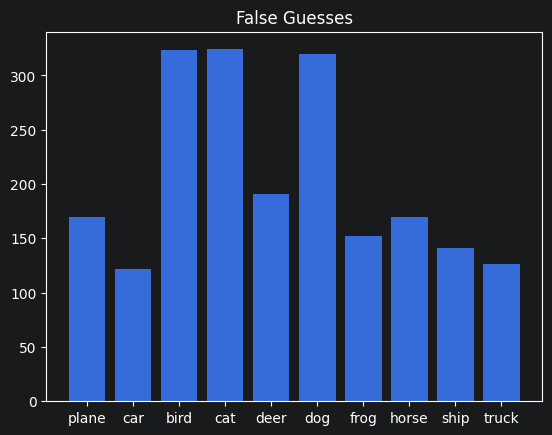

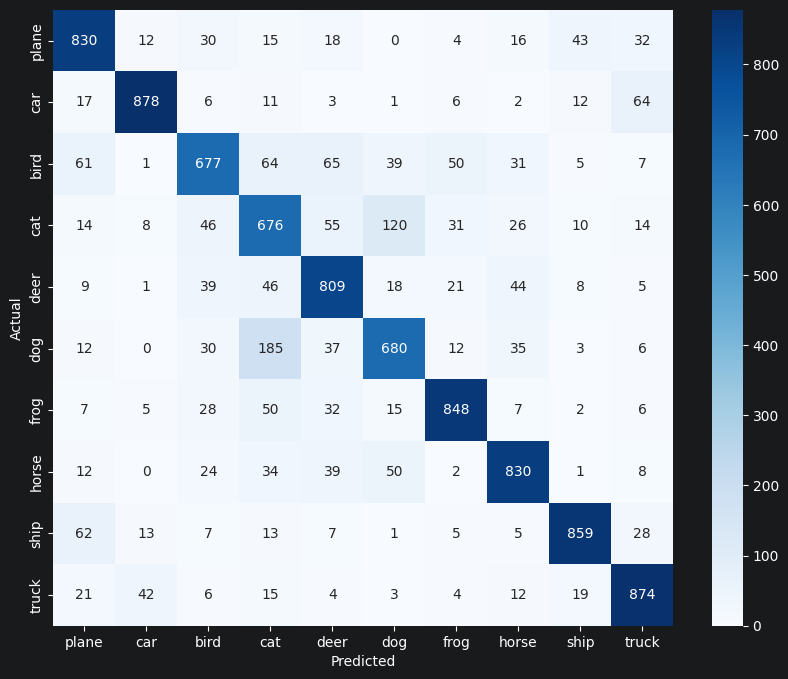

Test Accuracy on 10,000 images: 79.61%


In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Testing
print("\nBegin Testing:")
thing_model.eval()
correct = 0
total = 0
all_labels = []
all_preds = []
false_guesses = [0,0,0,0,0,0,0,0,0,0]
# Turn off gradient tracking to save memory and compute power during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = thing_model(images)

        # Get the index of the highest logit value (this is the predicted digit)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        for i in range(len(predicted)):
            if predicted[i] != labels[i]:
                false_guesses[labels[i]] += 1
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.tolist())
        all_preds.extend(predicted.tolist())

plt.bar(class_names, false_guesses)
plt.title('False Guesses')
plt.show()

# Generate predictions for the whole test set
# (You'll need a list of all predictions and all labels)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
accuracy = 100 * correct / total
print(f"Test Accuracy on 10,000 images: {accuracy:.2f}%")

In [66]:
torch.save(thing_model.state_dict(), "models/cnn_model_v3.pt")

In [67]:
input_tensor = torch.randn(1, 3, 32, 32)
input_tensor = input_tensor.to(device)
torch.onnx.export(thing_model,
                  (input_tensor,),
                  "models/cnn_model_v3.onnx",
                  dynamo=False,
                  input_names=["input"],
                  external_data=False)

C:\Users\dackh\AppData\Local\Temp\ipykernel_32796\2917956133.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(thing_model,


In [68]:
import onnx

onnx_model = onnx.load("models/cnn_model.onnx")
onnx.checker.check_model(onnx_model)

In [69]:
import onnxruntime
import numpy as np
import torch

loaded_model = CNN()
loaded_model.load_state_dict(torch.load("models/cnn_model.pt", weights_only=True))
loaded_model.eval()

ort_session = onnxruntime.InferenceSession(
    "models/cnn_model.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
for i in range(30):
    image, label = test_dataset[i]

    # Use np.expand_dims to add the batch dimension at index 0
    x = np.expand_dims(image.numpy().astype(np.float32), axis=0)

    logits = ort_session.run(None, {"input": x})[0]
    pred = int(np.argmax(logits,axis=1)[0])

    torch_output = loaded_model(torch.from_numpy(x))
    print(f"Actual: {label}, Torch Predicted: {torch_output.argmax().item()}, Onnx Predicted: {pred}, "
          f"Equal: {pred == torch_output.argmax().item()}")

RuntimeError: Error(s) in loading state_dict for CNN:
	Missing key(s) in state_dict: "batchnorm2.weight", "batchnorm2.bias", "batchnorm2.running_mean", "batchnorm2.running_var", "conv3.weight", "conv3.bias", "batchnorm3.weight", "batchnorm3.bias", "batchnorm3.running_mean", "batchnorm3.running_var". 
	size mismatch for conv1.weight: copying a param with shape torch.Size([10, 3, 5, 5]) from checkpoint, the shape in current model is torch.Size([15, 3, 5, 5]).
	size mismatch for conv1.bias: copying a param with shape torch.Size([10]) from checkpoint, the shape in current model is torch.Size([15]).
	size mismatch for conv2.weight: copying a param with shape torch.Size([15, 10, 5, 5]) from checkpoint, the shape in current model is torch.Size([30, 15, 5, 5]).
	size mismatch for conv2.bias: copying a param with shape torch.Size([15]) from checkpoint, the shape in current model is torch.Size([30]).
	size mismatch for fc1.weight: copying a param with shape torch.Size([120, 375]) from checkpoint